In [1]:
from tensorflow.keras.datasets import fashion_mnist

(train_X, train_y), (test_X, test_y) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist



mask_train = (train_y == 0) | (train_y == 1)
X_train = train_X[mask_train].reshape(-1, 784) / 255.0
y_train = train_y[mask_train].reshape(-1, 1)

mask_test = (test_y == 0) | (test_y == 1)
X_test = test_X[mask_test].reshape(-1, 784) / 255.0
y_test = test_y[mask_test].reshape(-1, 1)

print(f"Data is ready! Training set size: {X_train.shape}")

Data is ready! Training set size: (12000, 784)


In [20]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def init_params():
    np.random.seed(42)
    return {
        "W1": np.random.randn(784, 64) * 0.01, "b1": np.zeros((1, 64)),
        "W2": np.random.randn(64, 1) * 0.01, "b2": np.zeros((1, 1))
    }

In [21]:
def forward_propagation(X, p):
    Z1 = np.dot(X, p["W1"]) + p["b1"]
    A1 = relu(Z1)
    Z2 = np.dot(A1, p["W2"]) + p["b2"]
    A2 = sigmoid(Z2)
    return A2, {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}

def train_model(X, y, epochs=100, lr=0.1):
    p = init_params()
    loss_history = []
    m = X.shape[0]

    for i in range(epochs):

        A2, cache = forward_propagation(X, p)


        loss = -(1/m) * np.sum(y * np.log(A2 + 1e-8) + (1-y) * np.log(1-A2 + 1e-8))
        loss_history.append(loss)

        dZ2 = A2 - y
        dW2 = (1/m) * np.dot(cache["A1"].T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

        dZ1 = np.dot(dZ2, p["W2"].T) * relu_derivative(cache["Z1"])
        dW1 = (1/m) * np.dot(X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)


        p["W1"] -= lr * dW1
        p["b1"] -= lr * db1
        p["W2"] -= lr * dW2
        p["b2"] -= lr * db2

        if i % 10 == 0:
            print(f"Epoch {i}, Loss: {loss:.4f}")

    return p, loss_history


trained_params, history = train_model(X_train, y_train)
print("Training Completed!")

Epoch 0, Loss: 0.6944
Epoch 10, Loss: 0.6549
Epoch 20, Loss: 0.4397
Epoch 30, Loss: 0.2178
Epoch 40, Loss: 0.1527
Epoch 50, Loss: 0.1262
Epoch 60, Loss: 0.1098
Epoch 70, Loss: 0.0979
Epoch 80, Loss: 0.0887
Epoch 90, Loss: 0.0815
Training Completed!


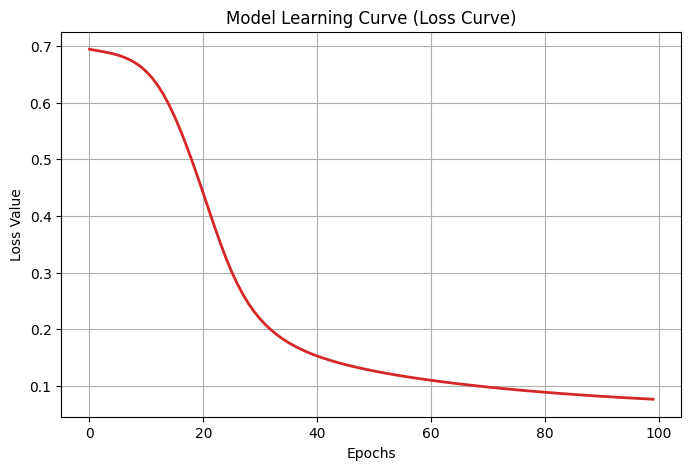

Final Results:
Training Accuracy: %97.62
Test Accuracy: %97.40


In [22]:

plt.figure(figsize=(8, 5))
plt.plot(history, color='tab:red', linewidth=2)
plt.title("Model Learning Curve (Loss Curve)")
plt.ylabel("Loss Value")
plt.xlabel("Epochs")
plt.grid(True)
plt.show()


def get_accuracy(X, y, p):
    predictions, _ = forward_propagation(X, p)
    predicted_classes = (predictions > 0.5).astype(int)
    return np.mean(predicted_classes == y) * 100

train_acc = get_accuracy(X_train, y_train, trained_params)
test_acc = get_accuracy(X_test, y_test, trained_params)

print(f"Final Results:")
print(f"Training Accuracy: %{train_acc:.2f}")
print(f"Test Accuracy: %{test_acc:.2f}")